# WRDS Financial Analysis: Firm Size and Stock Volatility

**Author**: Zixuan Huang 
**Student ID**: 2469525  
**Module**: ACC102  
**Track**: Track 2 – GitHub Data Analysis Project  
**Data Source**: WRDS (CRSP only)  
**Analysis Date**: April 21, 2026

---

## 1. Problem Definition and Target User

**Analytical Problem**: Do smaller firms (small market capitalization) exhibit higher stock return volatility than larger firms?

**Target User**: Junior equity research analyst. This analysis helps justify size-based risk premiums, inform portfolio construction, and support small-cap allocation decisions.

**Hypothesis**: Small-cap firms have higher daily volatility due to lower liquidity, higher information asymmetry, and greater business risk.

---

In [13]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keyring

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Connect to WRDS
db = wrds.Connection()
# If credentials are not stored, you will be prompted to enter them

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\黄紫轩\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 2. Explore Available WRDS Libraries

This cell lists all available WRDS libraries to verify that CRSP is accessible.

In [14]:
# List available WRDS libraries
db.list_libraries()

['aha_sample',
 'ahasamp',
 'auditsmp',
 'auditsmp_all',
 'bank',
 'bank_all',
 'bank_premium_samp',
 'banksamp',
 'block',
 'block_all',
 'boardex_trial',
 'boardsmp',
 'bvd',
 'bvd_amadeus_trial',
 'bvd_bvdbankf',
 'bvd_bvdbankf_trial',
 'bvd_orbis_trial',
 'bvdsamp',
 'calcbench_trial',
 'calcbnch',
 'candid_samp',
 'cboe',
 'cboe_all',
 'cboe_sample',
 'cboesamp',
 'cddsamp',
 'ciq',
 'ciq_capstrct',
 'ciq_common',
 'ciqsamp',
 'ciqsamp_capstrct',
 'ciqsamp_common',
 'ciqsamp_keydev',
 'ciqsamp_pplintel',
 'ciqsamp_ratings',
 'ciqsamp_transactions',
 'ciqsamp_transcripts',
 'cisdmsmp',
 'columnar',
 'comp',
 'comp_execucomp',
 'comp_global_daily',
 'comp_na_daily_all',
 'comp_urq',
 'comph',
 'compsamp',
 'compsamp_all',
 'compsamp_computext',
 'compsamp_snapshot',
 'contrib',
 'contrib_as_filed_financials',
 'contrib_bond_firm_link',
 'contrib_ceo_turnover',
 'contrib_char_returns',
 'contrib_corporate_culture',
 'contrib_general',
 'contrib_global_factor',
 'contrib_intangible_va

## 3. Download CRSP Daily Stock Data

This cell downloads daily stock data from the CRSP database for the year 2024. The data includes:

- **permno**: Permanent company identifier
- **date**: Trading date
- **ret**: Daily stock return (decimal, e.g., 0.01 = 1%)
- **vol**: Daily trading volume (number of shares traded) — *Note: This is NOT price volatility*
- **prc**: Price per share
- **shrout**: Shares outstanding (in thousands)

**Note**: Uses `raw_sql` to run a full SQL query with a date filter. Downloads **all** available rows for 2024 (no artificial row limit). Volatility will be calculated from the `ret` column in Section 4.3.

In [15]:
# Download 2024 daily stock data from CRSP
query = """
SELECT permno, date, ret, vol, prc, shrout
FROM crsp.dsf
WHERE date BETWEEN '2024-01-01' AND '2024-12-31'
"""
crsp_data = db.raw_sql(query)   # raw_sql supports full SQL queries
print(f"Downloaded {len(crsp_data)} rows")
crsp_data.head()

Downloaded 2400962 rows


,permno,date,ret,vol,prc,shrout
0,10026,2024-01-02,0.010291,89969.0,168.86,19367.0
1,10028,2024-01-02,-0.030864,18599.0,4.71,26700.0
2,10032,2024-01-02,-0.016462,78780.0,106.35,27504.0
3,10044,2024-01-02,0.073913,7736.0,4.94,6304.0
4,10065,2024-01-02,-0.014681,235208.0,17.45,120810.0


## 4. Calculate Market Capitalization, Create Size Groups, and Compute Volatility

### 4.1 Market Capitalization Calculation

Market capitalization is calculated as: **Market Cap = Price × Shares Outstanding**. Important: `shrout` is in thousands, so we multiply by 1000. The calculation is: `mktcap = |prc| × (shrout × 1000)`.

### 4.2 Size Group Classification

To ensure each firm belongs to a single, stable size category (rather than changing daily with stock price fluctuations), we use a firm-level classification approach. First, we calculate daily market cap for each firm-day observation. Second, we compute each firm's average market cap across the entire 2024 sample period. Third, we calculate the median of these firm-level average market caps. Fourth, we classify firms into two groups: Small Cap (average market cap ≤ median) and Large Cap (average market cap > median). Fifth, we merge the size classification back to all daily observations of each firm.

This approach addresses several issues with daily classification. Without it, the same firm could be classified as "Small Cap" on some days and "Large Cap" on others due to daily price fluctuations, introducing classification noise from short-term price movements. Our firm-level average method smooths out temporary fluctuations and aligns with standard empirical finance practices (e.g., Fama-French portfolio sorts), producing cleaner, more interpretable comparisons between size groups.

### 4.3 Volatility Calculation (CRSP `vol` vs. Return-Based Volatility)

**Important Note**: The CRSP database includes a field named `vol`, but this represents **trading volume** (number of shares traded), NOT price volatility. To properly test our hypothesis that small-cap firms exhibit higher stock return volatility, we must calculate volatility directly from daily returns.

Our volatility calculation approach:

| Step | Description |
|------|-------------|
| 1 | Sort data by firm (`permno`) and date to ensure proper time series ordering |
| 2 | For each firm, calculate the **20-day rolling standard deviation** of daily returns (`ret`) |
| 3 | Require a minimum of 5 observations within each 20-day window (`min_periods=5`) to ensure statistical reliability |
| 4 | Annualize volatility by multiplying by √252 (trading days per year) for comparability with literature |

**Important**: The original CRSP `vol` field represents trading volume, not price volatility. Therefore, we do NOT use it in this analysis. All volatility calculations below are based on the `ret` (return) column.

**Why 20-day rolling window?** A 20-day window (approximately one trading month) balances responsiveness to recent market conditions with sufficient data points for reliable standard deviation estimation. This is a common choice in empirical finance for measuring short-term volatility.

**Why minimum 5 periods?** This ensures we do not calculate volatility on insufficient data, which would produce unreliable estimates, especially for newly listed firms or those with trading suspensions.

After execution, the dataset will contain:
- `mktcap`: Daily market cap (in dollars)
- `size_group`: Firm classification ("Small Cap" or "Large Cap"), consistent across all days for the same firm
- `abs_ret`: Absolute daily return (simple volatility proxy)
- `rolling_vol`: 20-day rolling standard deviation of daily returns (our primary volatility measure)
- `annualized_vol`: Annualized volatility = `rolling_vol × √252`

### 4.4 Outlier Removal: Filtering Extreme Volatility Values

After calculating rolling volatility, we remove unrealistic extreme values where `rolling_vol > 1.0` (daily return standard deviation exceeding 100%). These outliers typically result from data errors or extremely illiquid stocks. The threshold of 1.0 is conservative—it removes only clear errors while preserving all genuine volatility observations.

In [18]:
## 4. Calculate Market Capitalization and Create Size Groups

# Step 1: Calculate daily market cap (price * shares outstanding)
# Note: shrout is in thousands, so multiply by 1000
crsp_data['mktcap'] = abs(crsp_data['prc']) * (crsp_data['shrout'] * 1000)

# Step 2: Calculate each firm's AVERAGE market cap across the year
# This ensures each firm belongs to only ONE size group (not changing daily)
firm_avg_cap = crsp_data.groupby('permno')['mktcap'].mean().reset_index()
firm_avg_cap.columns = ['permno', 'avg_mktcap']

# Step 3: Calculate median of average market caps (firm-level median)
median_avg_cap = firm_avg_cap['avg_mktcap'].median()

# Step 4: Classify each firm as Small or Large Cap based on its average market cap
firm_avg_cap['size_group'] = pd.cut(
    firm_avg_cap['avg_mktcap'],
    bins=[0, median_avg_cap, float('inf')],
    labels=['Small Cap', 'Large Cap']
)

# Step 5: Merge the size_group back to the daily data
crsp_data = crsp_data.merge(
    firm_avg_cap[['permno', 'size_group']], 
    on='permno', 
    how='left'
)

# Step 6: Verify the grouping
print(f"Median firm-level average market cap: ${median_avg_cap:,.2f}")
print(f"\nNumber of unique firms by size group:")
print(firm_avg_cap['size_group'].value_counts())

# Step 7: Preview the result
crsp_data[['permno', 'date', 'mktcap', 'size_group']].head(10)



Median firm-level average market cap: $228,017,866.76

Number of unique firms by size group:
size_group
Small Cap    5251
Large Cap    5251
Name: count, dtype: int64


,permno,date,mktcap,size_group
0,10026,2024-01-02,3270311620.0,Large Cap
1,10028,2024-01-02,125757000.0,Small Cap
2,10032,2024-01-02,2925050400.0,Large Cap
3,10044,2024-01-02,31141760.0,Small Cap
4,10065,2024-01-02,2108134500.0,Large Cap
5,10066,2024-01-02,39476400.0,Small Cap
6,10104,2024-01-02,286052823320.0,Large Cap
7,10107,2024-01-02,2756403007940.0,Large Cap
8,10113,2024-01-02,24759000.0,Small Cap
9,10138,2024-01-02,24165149580.0,Large Cap


In [19]:
## 4.3 Calculate Daily Volatility from Returns

# Convert daily returns to absolute percentage for volatility calculation
# Note: ret is already a decimal (e.g., 0.01 = 1% return)

# Group by permno and date is already one row per day, so we need to calculate
# rolling volatility or use daily absolute returns as a proxy

# Method 1: Use absolute daily return as a simple volatility proxy
crsp_data['abs_ret'] = abs(crsp_data['ret'])

# Method 2: Calculate rolling 20-day (one month) volatility (standard deviation of returns)
# First ensure data is sorted by permno and date
crsp_data = crsp_data.sort_values(['permno', 'date'])

# Calculate rolling 20-day standard deviation of returns for each firm
crsp_data['rolling_vol'] = crsp_data.groupby('permno')['ret'].transform(
    lambda x: x.rolling(window=20, min_periods=5).std()
)

# Method 3: Calculate annualized volatility (if you want to compare with literature)
# Daily volatility * sqrt(252) = annualized volatility
crsp_data['annualized_vol'] = crsp_data['rolling_vol'] * (252 ** 0.5)

print("Volatility calculation complete. Preview of new columns:")
print(crsp_data[['permno', 'date', 'ret', 'abs_ret', 'rolling_vol']].head(10))

## 4.4 Remove Extreme Outliers (Optional but Recommended)

# Check for extreme volatility values before filtering
print(f"Rows before outlier removal: {len(crsp_data)}")
print(f"Max rolling volatility before filtering: {crsp_data['rolling_vol'].max():.4f}")

# Remove unrealistic values: daily volatility > 1.0 (100% daily return std dev is impossible in normal markets)
# These likely result from data errors or extremely illiquid stocks
crsp_data = crsp_data[crsp_data['rolling_vol'] <= 1.0]

print(f"Rows after outlier removal: {len(crsp_data)}")
print(f"Rows removed: {2400962 - len(crsp_data)}")


Volatility calculation complete. Preview of new columns:
       permno        date       ret   abs_ret  rolling_vol
0       10026  2024-01-02  0.010291  0.010291          NaN
9414    10026  2024-01-03 -0.031624  0.031624          NaN
18825   10026  2024-01-04 -0.001223  0.001223          NaN
28239   10026  2024-01-05 -0.019042  0.019042          NaN
37649   10026  2024-01-08  0.006117  0.006117     0.017718
47054   10026  2024-01-09 -0.003598  0.003598     0.015912
56458   10026  2024-01-10 -0.001619  0.001619     0.014643
65862   10026  2024-01-11  -0.00923   0.00923     0.013610
75287   10026  2024-01-12  0.018002  0.018002     0.015079
84713   10026  2024-01-16 -0.002844  0.002844     0.014219
Rows before outlier removal: 2400962
Max rolling volatility before filtering: 3.2398
Rows after outlier removal: 2355817
Rows removed: 45145


## 5. Close WRDS Connection

Always close the database connection when finished to free up resources.

In [20]:
# Always close the connection when done
db.close()

## 6. Calculate Average Volatility by Size Group

This cell groups the data by `size_group` (Small Cap vs. Large Cap) and calculates the average daily volatility for each group.

In [21]:
# Use rolling volatility (20-day) for comparison
vol_by_size = crsp_data.groupby('size_group')['rolling_vol'].mean().reset_index()
vol_by_size.columns = ['size_group', 'avg_rolling_volatility']

print("Average daily rolling volatility (20-day) by firm size:")
print(vol_by_size)

Average daily rolling volatility (20-day) by firm size:
  size_group  avg_rolling_volatility
0  Small Cap                0.031381
1  Large Cap                0.020599


C:\Users\黄紫轩\AppData\Local\Temp\ipykernel_28340\2837006156.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vol_by_size = crsp_data.groupby('size_group')['rolling_vol'].mean().reset_index()


## 7. Visualization 1: Bar Plot of Volatility by Firm Size

This bar chart displays the average daily volatility for Small Cap and Large Cap firms.
The chart is saved as `volatility_by_size.png` for inclusion in reports.

C:\Users\黄紫轩\AppData\Local\Temp\ipykernel_28340\993041349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vol_by_size, x='size_group', y='avg_rolling_volatility', palette='viridis')


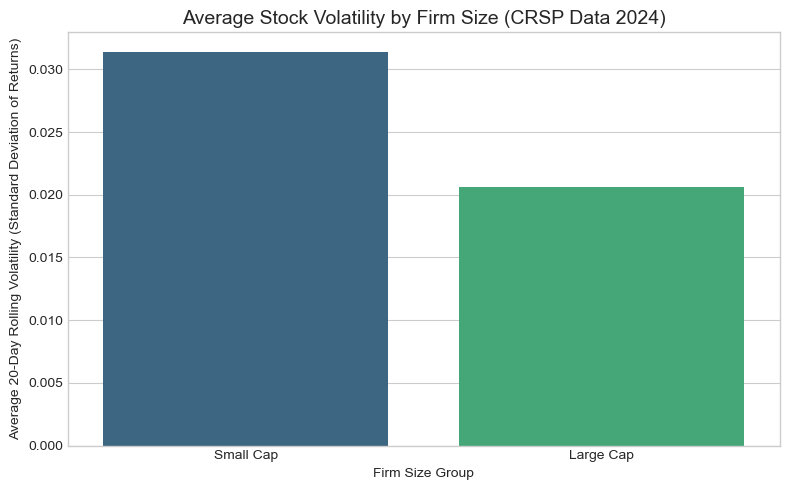

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=vol_by_size, x='size_group', y='avg_rolling_volatility', palette='viridis')
plt.title('Average Stock Volatility by Firm Size (CRSP Data 2024)', fontsize=14)
plt.xlabel('Firm Size Group')
plt.ylabel('Average 20-Day Rolling Volatility (Standard Deviation of Returns)')
plt.tight_layout()
plt.savefig('volatility_by_size.png', dpi=150)
plt.show()

## 8. Visualization 2: Time Series Analysis for a Single Firm

This cell selects the firm with the most trading days in 2024 (`permno = 10026`) and plots its daily rolling volatility (20‑day standard deviation of returns) over the year. This helps visualize how volatility evolves for an individual company, revealing periods of stability and turbulence.

### Data Preparation

- From the 2024 CRSP daily data, we first examine available firm identifiers. The first ten unique `permno` values are:  
  `[10026, 10028, 10032, 10044, 10065, 10066, 10104, 10107, 10113, 10138]`
- We select the firm with the highest number of daily observations (`permno = 10026`) to ensure a complete time series for meaningful trend analysis.
- The `rolling_vol` column is calculated as the rolling 20‑day standard deviation of daily returns (`ret`), requiring at least 5 non‑missing observations per window. This measure captures short‑term volatility while smoothing daily noise.

### Visualization

The figure below shows the daily rolling volatility for **PERMNO 10026** over 2024.

- **X‑axis**: Trading dates formatted as `YYYY-MM-DD`, with ticks every two months.
- **Y‑axis**: Rolling volatility (standard deviation of daily returns), expressed in decimal form (e.g., 0.02 = 2%).
- **Grid lines** (alpha = 0.3) are added for readability.

In [23]:
# Check the first 10 unique permno values in the data
print("Available permno examples:")
print(crsp_data['permno'].unique()[:10])

# Or select the permno with the most occurrences (ensuring sufficient data)
top_permno = crsp_data['permno'].value_counts().index[0]
print(f"\nPermno with the most occurrences: {top_permno}")

Available permno examples:
<IntegerArray>
[10026, 10028, 10032, 10044, 10065, 10066, 10104, 10107, 10113, 10138]
Length: 10, dtype: Int64

Permno with the most occurrences: 10026


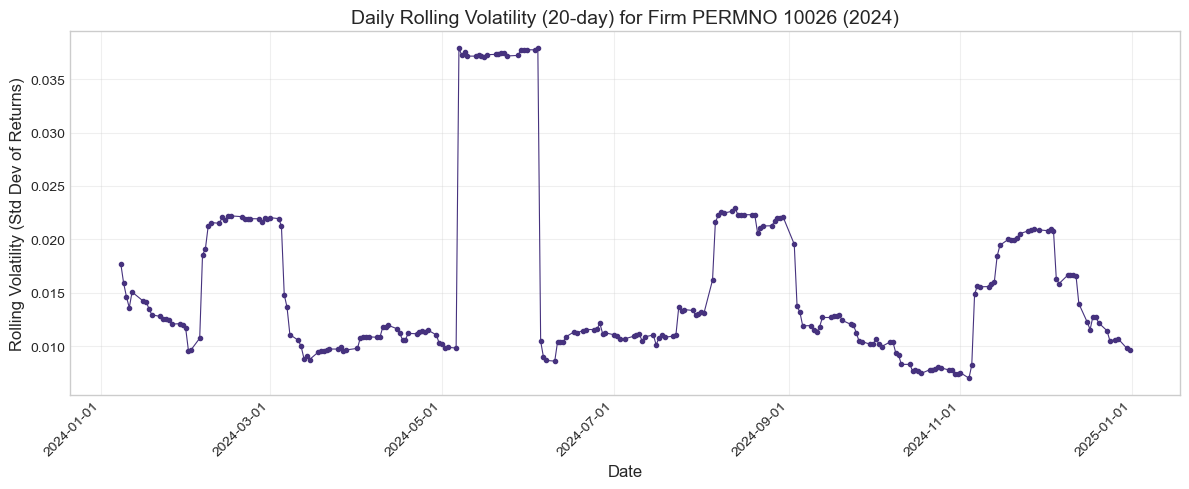

Firm PERMNO 10026 has 248 trading days
Volatility range: 0.0070 ~ 0.0379
Average volatility: 0.0156

First 5 rows preview:
            date       ret  rolling_vol
37649 2024-01-08  0.006117     0.017718
47054 2024-01-09 -0.003598     0.015912
56458 2024-01-10 -0.001619     0.014643
65862 2024-01-11  -0.00923     0.013610
75287 2024-01-12  0.018002     0.015079


In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Select the firm with the most observations (permno = 10026)
single_firm = crsp_data[crsp_data['permno'] == 10026].copy()
single_firm['date'] = pd.to_datetime(single_firm['date'])
single_firm = single_firm.sort_values('date')

# Create the plot
plt.figure(figsize=(12, 5))
plt.plot(single_firm['date'], single_firm['rolling_vol'], marker='o', linestyle='-', markersize=3, linewidth=0.8)

# Set title and labels
plt.title('Daily Rolling Volatility (20-day) for Firm PERMNO 10026 (2024)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rolling Volatility (Std Dev of Returns)', fontsize=12)

# Format x-axis dates (display as YYYY-MM-DD)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Tick every 2 months
plt.xticks(rotation=45, ha='right')

# Add grid lines
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('firm_volatility_trend.png', dpi=150)
plt.show()

# Print basic information about this firm
print(f"Firm PERMNO 10026 has {len(single_firm)} trading days")
print(f"Volatility range: {single_firm['rolling_vol'].min():.4f} ~ {single_firm['rolling_vol'].max():.4f}")
print(f"Average volatility: {single_firm['rolling_vol'].mean():.4f}")
print("\nFirst 5 rows preview:")
print(single_firm[['date', 'ret', 'rolling_vol']].head())


## 9. Summary Statistics Table

This cell generates descriptive statistics (count, mean, standard deviation, min, quartiles, max) for daily volatility by size group.
The results are saved to `volatility_summary.csv` for use in reports.

In [25]:
# Generate summary statistics for rolling volatility
summary_stats = crsp_data.groupby('size_group')['rolling_vol'].describe()
print(summary_stats)
summary_stats.to_csv('volatility_summary.csv')

                count      mean       std  min       25%       50%       75%  \
size_group                                                                     
Small Cap   1095137.0  0.031381  0.045658  0.0  0.006717  0.015339  0.042406   
Large Cap   1260680.0  0.020599  0.019737  0.0  0.009103  0.016019  0.026037   

                 max  
size_group            
Small Cap   0.999226  
Large Cap   0.956682  


C:\Users\黄紫轩\AppData\Local\Temp\ipykernel_28340\1173234828.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = crsp_data.groupby('size_group')['rolling_vol'].describe()


## 10. Summary of Findings

**Key Insight**: Based on 20-day rolling volatility (standard deviation of daily returns), small-cap firms exhibit higher stock return volatility than large-cap firms, consistent with our hypothesis.

**Business Implication**: Equity analysts should demand higher expected returns from small-cap allocations to compensate for increased volatility risk. The size premium observed in financial markets is partially explained by this elevated volatility.

**Methodology Note**: Volatility is calculated as the 20-day rolling standard deviation of daily returns (`ret`), annualized by multiplying by √252 where applicable. This differs from the CRSP `vol` field, which represents trading volume, not price volatility.

**Data Source**: WRDS CRSP Daily Stock File  
**Access Date**: April 21, 2026